In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_71673/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


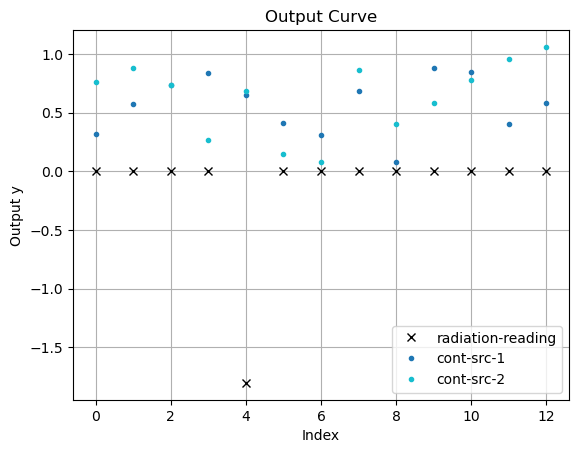

In [3]:
#Process data
%run data_handler.ipynb

In [11]:
X = inputs
y = outputs

In [12]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


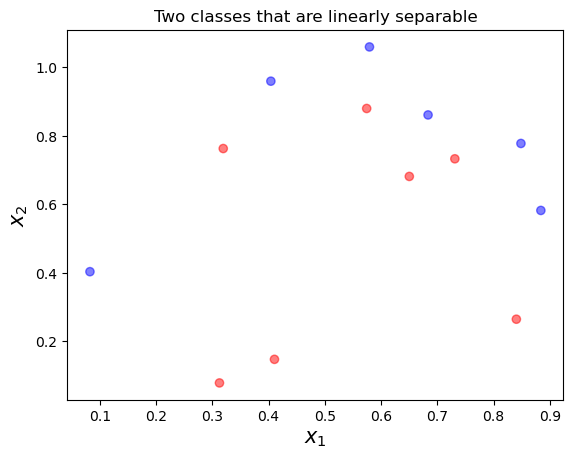

In [24]:
n_red = 7
n_blue = 6  # total = 13

color = np.concatenate((np.repeat("red", n_red), np.repeat("blue", n_blue)))

plt.scatter(X[:, 0], X[:, 1], c=color, alpha=0.5)
plt.xlabel("$x_1$", size=15)
plt.ylabel("$x_2$", size=15)
plt.title("Two classes that are linearly separable")
plt.show()

In [30]:
clf = svm.SVC(kernel='rbf')
clf.fit(X, y)
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when all samples belong to the same class.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o", zoom_factor = 10);
    ax=plt.gca();
    plt.title("Linear decision boundary")
    plt.show();

In [14]:
find_best_candidate(query_results)

Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.75124539, 0.74297657]), 'score': 0.9999998083697721, 'dim': 2}
{'method': 'PI', 'xi': 0.05, 'kappa': None, 'x': array([0.75124539, 0.74297657]), 'score': 0.9999986504637735, 'dim': 2}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.75124539, 0.74297657]), 'score': 0.9999873287633881, 'dim': 2}
{'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.80182027, 0.71022284]), 'score': 1.3639636416498213, 'dim': 2}
{'method': 'UCB', 'xi': None, 'kappa': 2.0, 'x': array([0.56917583, 1.04867809]), 'score': 2.0866630842642238, 'dim': 2}
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.57929081, 1.059596  ]), 'score': 3.0545856586677815, 'dim': 2}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.78159032, 0.75389448]), 'score': 0.795813533896603, 'dim': 2}
{'method': 'EI', 'xi': 0.05, 'kappa': None, 'x': array([0.78159032, 0.75389448]), 'score': 0.7558174827070906, 'dim':

{'method': 'UCB',
 'xi': None,
 'kappa': 3.0,
 'x': array([0.57929081, 1.059596  ]),
 'score': 3.0545856586677815,
 'dim': 2}

In [15]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file
12    0.751245    0.742977                NaN  week-x
13    0.751245    0.742977                NaN  week-x
14    0.751245    0.742977                NaN  week-x
15    0.801820    0.710223                NaN  week-x
16    0.569176    1.048678                NaN  week-x
17    0.579291    1.059596  

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_24054/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


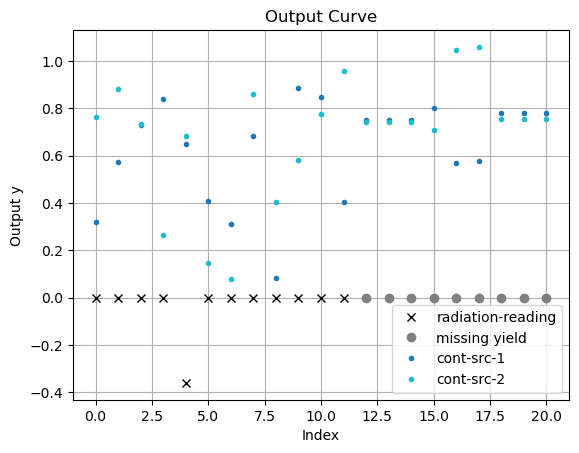

In [23]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')